# “A Comprehensive Statistical Analysis and Price Prediction of Airline Ticket Pricing Factors”

# Objectives

To analyze how airline companies vary in ticket pricing strategies and identify premium and low-cost carriers in the market.

To examine how the number of stops affects ticket prices and determine whether direct flights are significantly more expensive than connecting flights.

To evaluate the relationship between flight duration and ticket price to understand whether longer travel time influences fare levels.

To assess how advance booking (days left before departure) impacts ticket prices and determine the best time to book flights.

To compare ticket prices between Economy and Business class in order to measure the service-based pricing difference.

To analyze route-wise (source and destination city) pricing trends to identify high-demand and high-revenue routes.

To study the influence of departure time on ticket prices to understand peak-time and off-peak pricing behavior.

To develop a statistical model to predict airline ticket prices based on operational and booking-related factors.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
df=pd.read_csv("airlines_flights_data.csv")

In [7]:
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,Duration(minutes),days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,130,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,140,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,130,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,135,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,140,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,605,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,625,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,830,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,600,49,81585


In [8]:
df.rename(columns={'Duration(minutes)': 'duration'}, inplace=True)


In [9]:
df.drop('index', axis=1, inplace=True)



In [10]:
df.shape

(300153, 11)

In [11]:
df.head(10)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,130,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,140,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,130,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,135,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,140,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,140,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,125,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,130,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,130,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,135,1,5954


In [12]:
df.tail()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,605,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,625,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,830,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,600,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,605,49,81585


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [14]:
df.dtypes

airline             object
flight              object
source_city         object
departure_time      object
stops               object
arrival_time        object
destination_city    object
class               object
duration             int64
days_left            int64
price                int64
dtype: object

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           300153 non-null  object
 1   flight            300153 non-null  object
 2   source_city       300153 non-null  object
 3   departure_time    300153 non-null  object
 4   stops             300153 non-null  object
 5   arrival_time      300153 non-null  object
 6   destination_city  300153 non-null  object
 7   class             300153 non-null  object
 8   duration          300153 non-null  int64 
 9   days_left         300153 non-null  int64 
 10  price             300153 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 25.2+ MB


In [16]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [17]:
df.drop_duplicates()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,130,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,140,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,130,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,135,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,140,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,605,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,625,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,830,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,600,49,81585


In [18]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [19]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
duration,300153.0,733.259055,431.518381,50.0,410.0,675.0,970.0,2990.0
days_left,300153.0,26.004751,13.561004,1.0,15.0,26.0,38.0,49.0
price,300153.0,20889.660523,22697.767366,1105.0,4783.0,7425.0,42521.0,123071.0


# interpretation
The dataset contains 300,153 flight records.

Duration ranges from 50 to 2990 minutes, showing wide variability in travel time.

Days_Left has a mean and median of 26 days, indicating relatively balanced booking behavior.

Ticket Price shows strong right skewness (Mean ₹20,889 > Median ₹7,425), indicating presence of high-priced premium tickets.

High standard deviation in price suggests large variability across airlines and classes.


In [20]:
#  airlines in datasets 
df['airline'].nunique()

6

In [21]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [22]:
airlines_frequency = df['airline'].value_counts(ascending=False)
airlines_frequency

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [23]:
median_price = df.groupby('airline')['price'].median().sort_values()

print(median_price)


airline
AirAsia       3276.0
Indigo        4453.0
GO_FIRST      5336.0
SpiceJet      5654.0
Air_India    11520.0
Vistara      15543.0
Name: price, dtype: float64


# 1.To analyze how airline companies vary in ticket pricing strategies and identify premium and low-cost carriers in the market.

In [24]:
!pip install statsmodels


In [25]:
mean_price = df.groupby('airline')['price'].mean().sort_values()
print(mean_price)



airline
AirAsia       4091.072742
Indigo        5324.216303
GO_FIRST      5652.007595
SpiceJet      6179.278881
Air_India    23507.019112
Vistara      30396.536302
Name: price, dtype: float64


# Boxplot 

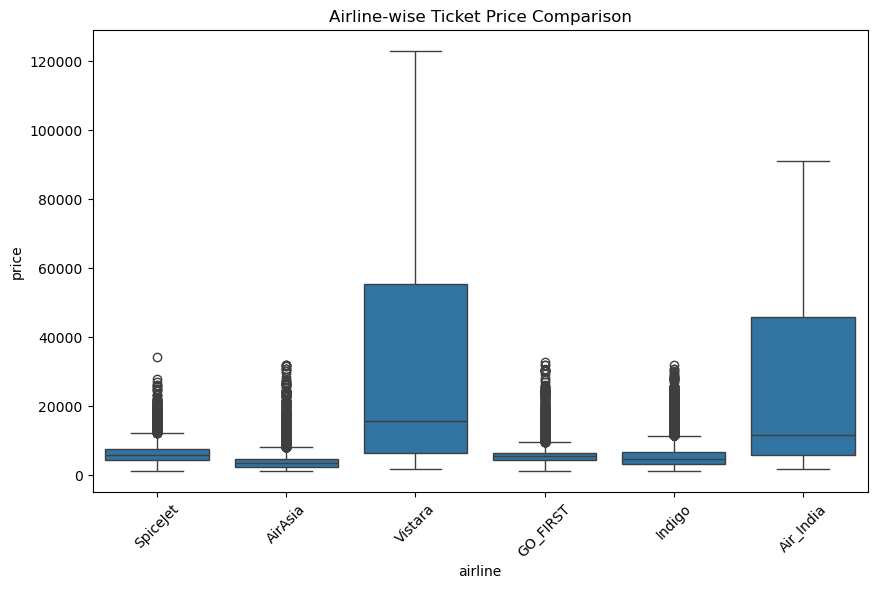

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Airline-wise Ticket Price Comparison")
plt.show()


# Interpretation
The boxplot shows clear variation in ticket prices among airlines. Vistara and Air India have higher median prices and a wider price range, indicating premium pricing strategies. AirAsia has the lowest median price, suggesting it operates as a low-cost carrier. Indigo, GO FIRST, and SpiceJet fall in the mid-price range. Overall, the plot indicates significant differences in airline pricing patterns.

# 1. Histogram

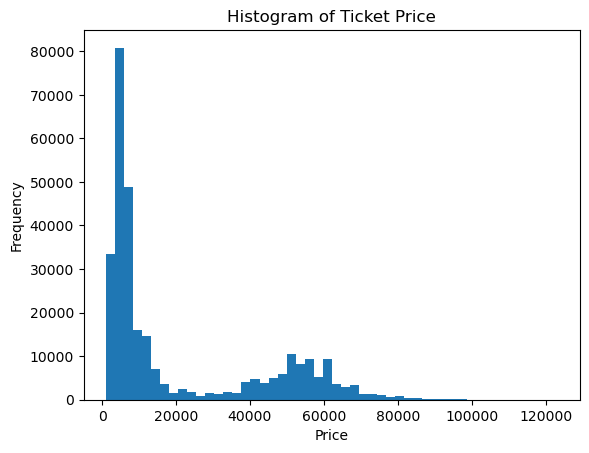

In [27]:
plt.hist(df['price'], bins=50)
plt.title("Histogram of Ticket Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# Interpretation
The histogram shows that ticket prices are positively skewed (right-skewed) and not normally distributed. Most ticket prices are concentrated in the lower range, while a few tickets have very high values. The long right tail indicates the presence of premium or business-class fares. Therefore, the price data shows high variability and skewness.

# 2.Q–Q Plot

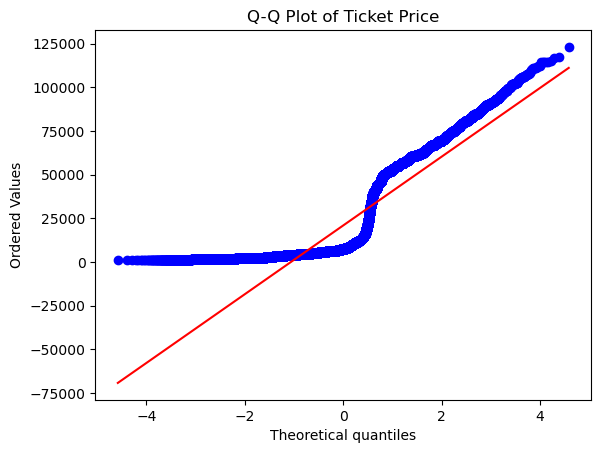

In [28]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['price'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Ticket Price")
plt.show()


# Interpretation
The Q–Q plot shows that the data points do not follow the straight reference line, especially at the upper tail. This indicates that the ticket price variable is not normally distributed. The strong upward deviation confirms positive skewness and the presence of high-value outliers. Therefore, the normality assumption is violated for ticket prices.

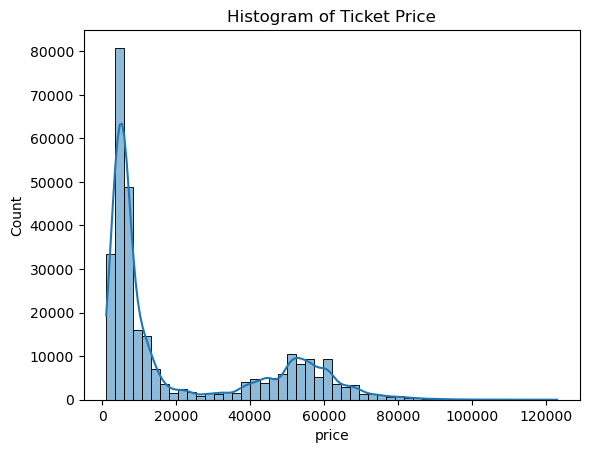

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins=50, kde=True)
plt.title("Histogram of Ticket Price")
plt.show()


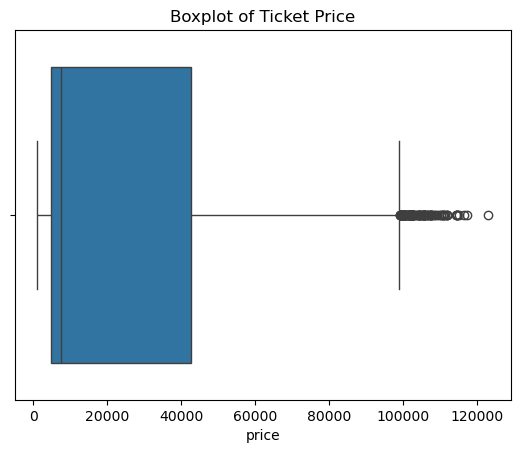

In [30]:
sns.boxplot(x=df['price'])
plt.title("Boxplot of Ticket Price")
plt.show()


# 3.Skewness and Kurtosis

In [31]:
print("Skewness:", df['price'].skew())
print("Kurtosis:", df['price'].kurt())


Skewness: 1.0613772532064343
Kurtosis: -0.3962927186960772


# Interpretation
The skewness value (1.06) indicates that the ticket price distribution is positively skewed. This means most prices are concentrated at lower values with some high-price outliers. The kurtosis value (-0.39) shows the distribution is slightly flatter than normal. Therefore, the ticket price data is not normally distributed.

# Kolmogorov-Smirnov Test

In [32]:
from scipy import stats
import numpy as np

# Standardize data
price_std = (df['price'] - df['price'].mean()) / df['price'].std()

# KS test
stat, p = stats.kstest(price_std, 'norm')

print(f"KS Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")


KS Statistic: 0.2782
P-value: 0.0000


# Interpretation
The Kolmogorov–Smirnov test produced a KS statistic of 0.2782 with a p-value of 0.0000. Since the p-value is less than 0.05, we reject the null hypothesis.
The ticket price data does not follow a normal distribution.


# Kruskal–Wallis Test

# Hypotheses

H₀: No significant difference in ticket prices among airlines.

H₁: At least one airline differs significantly.

In [33]:
from scipy import stats

groups = [group["price"].values for name, group in df.groupby("airline")]

stat, p = stats.kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("P-value:", p)


Kruskal-Wallis Statistic: 94612.80508823584
P-value: 0.0


# Interpretation:
The Kruskal–Wallis test statistic is 94612.81 with a p-value of 0.0. Since the p-value is less than 0.05, we reject the null hypothesis.
# Conclusion:
There is a statistically significant difference in ticket prices among airlines. This indicates that airlines follow different pricing strategies, with some operating as premium carriers and others as low-cost carriers.

In [34]:
!pip install scikit-posthocs


# Dunn’s Post-Hoc Test 

In [35]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(df, val_col='price', group_col='airline', p_adjust='bonferroni')

print(dunn)


                 AirAsia  Air_India      GO_FIRST         Indigo  \
AirAsia     1.000000e+00        0.0  0.000000e+00  4.260369e-269   
Air_India   0.000000e+00        1.0  0.000000e+00   0.000000e+00   
GO_FIRST    0.000000e+00        0.0  1.000000e+00   1.146237e-90   
Indigo     4.260369e-269        0.0  1.146237e-90   1.000000e+00   
SpiceJet    0.000000e+00        0.0  2.277123e-15  2.691152e-117   
Vistara     0.000000e+00        0.0  0.000000e+00   0.000000e+00   

                SpiceJet  Vistara  
AirAsia     0.000000e+00      0.0  
Air_India   0.000000e+00      0.0  
GO_FIRST    2.277123e-15      0.0  
Indigo     2.691152e-117      0.0  
SpiceJet    1.000000e+00      0.0  
Vistara     0.000000e+00      1.0  


# Interpretation
The Dunn’s test results show pairwise comparisons of ticket prices between airlines. Since most p-values are less than 0.05 (very close to 0), it indicates that there are statistically significant differences in ticket prices between almost all airline pairs.

This means that airlines follow distinctly different pricing strategies. In particular, premium airlines such as Vistara and Air India significantly differ from low-cost carriers like AirAsia, GO_FIRST, and SpiceJet

# Conclusion
The Dunn’s post-hoc test confirms that ticket prices differ significantly between almost all airlines. This demonstrates that airline companies follow distinct pricing strategies. Based on median price differences, Vistara and Air India can be identified as premium airlines, while AirAsia, GO_FIRST, and SpiceJet operate as low-cost carriers. These findings strongly support the objective of identifying airline-wise pricing variation in the market.

# Median Bar Chart

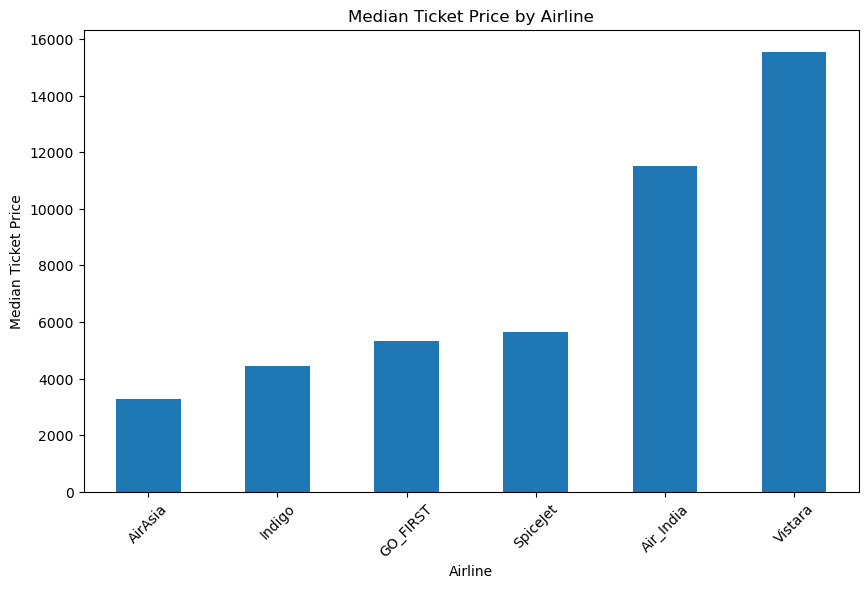

In [36]:
# Calculate median price for each airline
median_prices = df.groupby('airline')['price'].median().sort_values()

plt.figure(figsize=(10,6))
median_prices.plot(kind='bar')
plt.title("Median Ticket Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Median Ticket Price")
plt.xticks(rotation=45)
plt.show()


# Interpretation
The graph shows that Vistara has the highest median ticket price, indicating a premium pricing strategy, followed by Air India. AirAsia has the lowest median price, operating as a low-cost carrier. Indigo, GO FIRST, and SpiceJet fall in the mid-price range. This clearly reflects different airline market positions in real life.

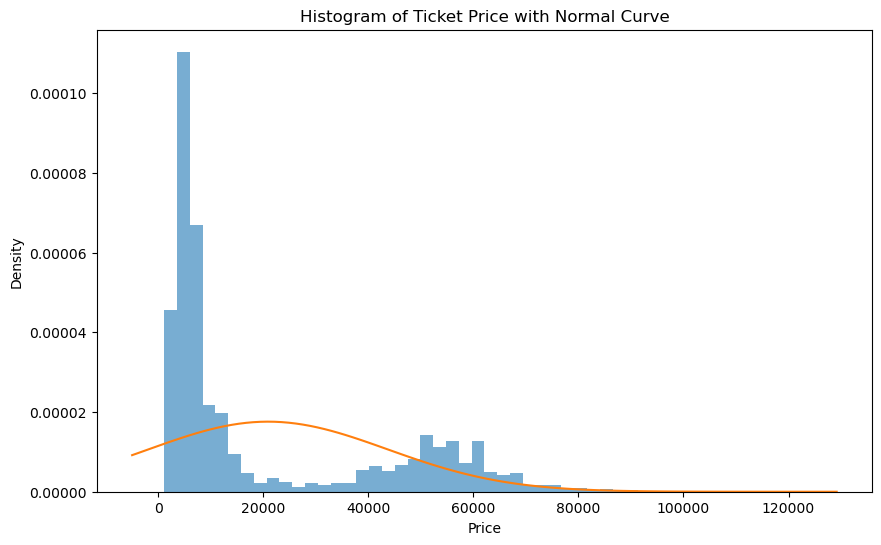

In [37]:
# histogram with normal curve
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Calculate mean and standard deviation
mean = df['price'].mean()
std = df['price'].std()

# Plot histogram (density=True for probability density)
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50, density=True, alpha=0.6)

# Generate x values for normal curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Plot normal distribution curve
p = norm.pdf(x, mean, std)
plt.plot(x, p)

plt.title("Histogram of Ticket Price with Normal Curve")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()


# 2.To examine how the number of stops affects ticket prices and determine whether direct flights are significantly more expensive than connecting flights.

# Median & IQR by Stops

In [38]:
summary = df.groupby('stops')['price'].agg(
    Median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

summary['IQR'] = summary['Q3'] - summary['Q1']
print(summary)


             Median      Q1       Q3      IQR
stops                                        
one          7959.0  5136.0  48851.0  43715.0
two_or_more  8307.0  6432.0  13419.0   6987.0
zero         4499.0  2586.0   8064.0   5478.0


# interpretation
The table shows that flights with two or more stops have the highest median ticket price (₹8,307), followed by one-stop flights (₹7,959), while direct flights (zero stops) have the lowest median price (₹4,499).

The IQR is largest for one-stop flights (₹43,715), indicating very high price variability in this category. In contrast, direct flights have a smaller IQR (₹5,478), showing more consistent pricing.

# Box plot

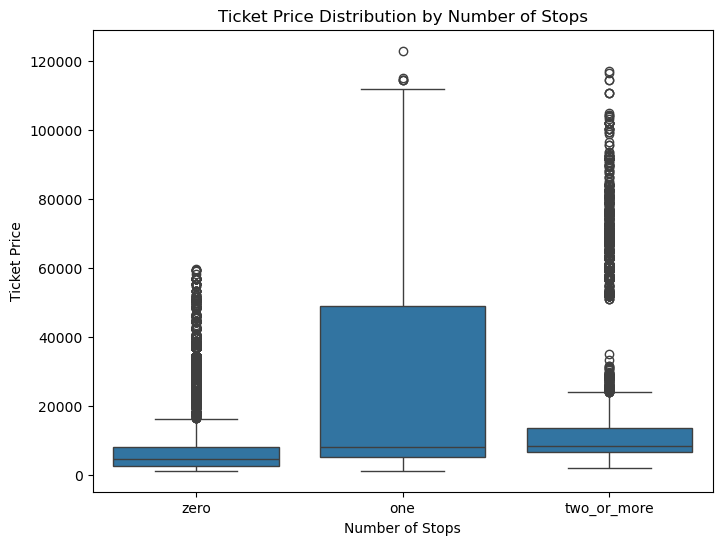

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='stops', y='price', data=df)
plt.title("Ticket Price Distribution by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Ticket Price")
plt.show()


# Interpretation
The boxplot shows that direct flights (zero stops) have the lowest median ticket price and a relatively smaller spread, indicating more consistent and affordable pricing.

Flights with one stop show a much wider spread and higher median price, suggesting large variability and higher fares in this category.

Flights with two or more stops also have a higher median price than direct flights and show many high-value outliers.

# Kruskal–Wallis Test (Compare All Stop Categories)

# Hypotheses
H₀: No significant difference in ticket prices based on number of stops.

H₁: At least one stop category differs significantly.

In [40]:
from scipy import stats

groups = [group["price"].values for name, group in df.groupby("stops")]

stat, p = stats.kruskal(*groups)

print(f"Kruskal-Wallis Statistic: {stat:.7f}")
print(f"P-value: {p:.7f}")


Kruskal-Wallis Statistic: 20484.2994311
P-value: 0.0000000


# Interpretation
The Kruskal–Wallis test produced a statistic of 20484.2994 with a p-value of 0.0000. Since the p-value is less than 0.05, we reject the null hypothesis.
# Conclusion
There is a statistically significant difference in ticket prices based on the number of stops. This means that at least one stop category (zero, one, or two or more stops) has a different median ticket price compared to the others.The number of stops significantly influences ticket pricing, indicating that direct and connecting flights are priced differently in the market.

# Mann–Whitney U Test (Direct vs Connecting)

# Hypothesis
H0:There is no significant difference in ticket prices between direct and connecting flights.

H1:There is a significant difference in ticket prices between direct and connecting flights.

In [41]:
df['flight_type'] = df['stops'].apply(lambda x: 'Direct' if x == 'zero' else 'Connecting')
direct = df[df['flight_type'] == 'Direct']['price']
connecting = df[df['flight_type'] == 'Connecting']['price']

stat, p = stats.mannwhitneyu(direct, connecting, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.4f}")
print(f"P-value: {p:.5f}")


Mann-Whitney U Statistic: 2549488655.5000
P-value: 0.00000


# Interpretation
The Mann–Whitney U test shows a p-value of 0.00000, which is less than 0.05, so we reject the null hypothesis. This indicates a statistically significant difference in ticket prices between direct and connecting flights. Therefore, the number of stops significantly affects ticket pricing.


# Median Bar Chart

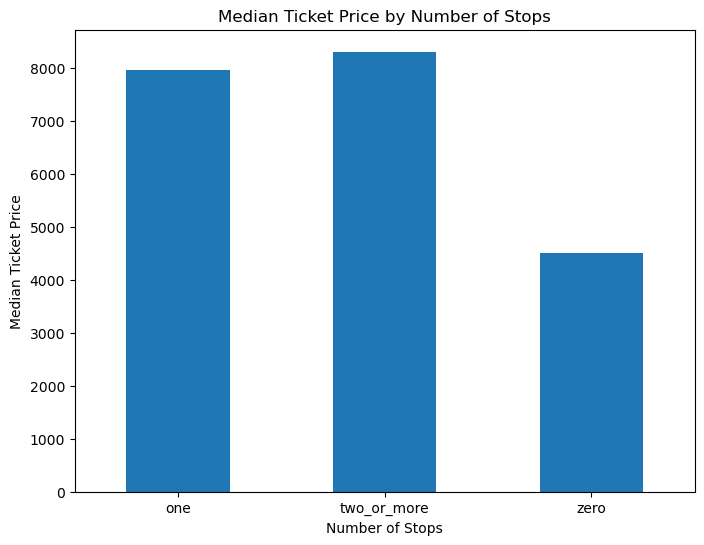

In [42]:
median_prices = df.groupby('stops')['price'].median()

plt.figure(figsize=(8,6))
median_prices.plot(kind='bar')
plt.title("Median Ticket Price by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Median Ticket Price")
plt.xticks(rotation=0)
plt.show()


# Interpretation
The graph shows that flights with two or more stops have the highest median ticket price, followed by one-stop flights, while direct flights (zero stops) have the lowest median price. This indicates that connecting flights generally cost more than direct flights. The difference suggests that the number of stops significantly influences ticket pricing. Overall, ticket prices tend to increase as the number of stops increases.

# Violin Plot

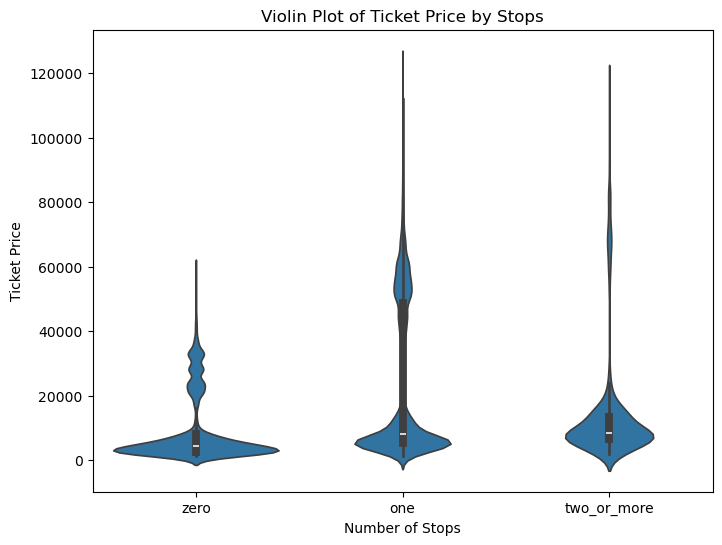

In [43]:
plt.figure(figsize=(8,6))
sns.violinplot(x='stops', y='price', data=df)
plt.title("Violin Plot of Ticket Price by Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Ticket Price")
plt.show()


# Interpretation
The violin plot shows the distribution of ticket prices for different stop categories. Direct flights (zero stops) have lower ticket prices concentrated in the lower range, indicating more affordable and consistent pricing. Flights with one stop and two or more stops show wider distributions and higher price densities at larger values, indicating higher and more variable ticket prices. The long upper tails in connecting flights suggest the presence of expensive premium fares.

 # Scatter Plot (Duration vs Price)

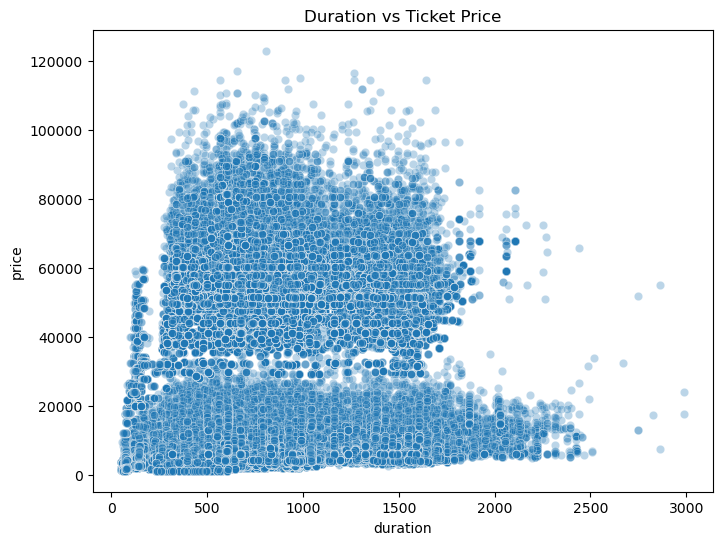

In [44]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='duration', y='price', data=df, alpha=0.3)
plt.title("Duration vs Ticket Price")
plt.show()


# Interpretation
The scatter plot shows a positive relationship between flight duration and ticket price. As the duration increases, ticket prices generally tend to increase. However, the wide spread of points indicates that duration alone does not determine price. Other factors such as airline, class, and stops also influence ticket pricing.

# Correlation Heatmap

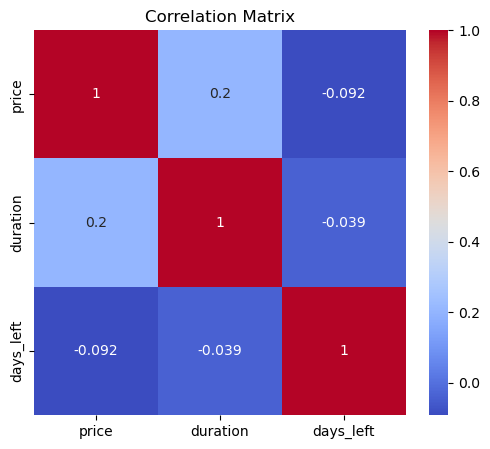

In [45]:
import numpy as np

plt.figure(figsize=(6,5))
sns.heatmap(df[['price','duration','days_left']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# Interpretation
The heatmap shows the correlation between price, duration, and days_left. There is a weak positive correlation (0.20) between duration and price, indicating that longer flights tend to have slightly higher prices. The correlation between price and days_left is weakly negative (-0.092), suggesting that booking earlier may slightly reduce ticket prices. Overall, the correlations are weak, meaning no strong linear relationship exists among these variables.

# Bar Chart (Median Price by Airline)

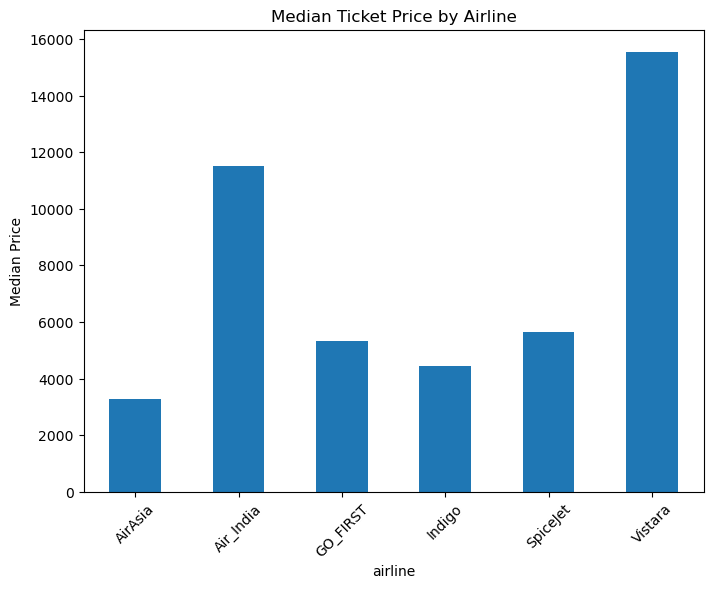

In [46]:
median_airline = df.groupby('airline')['price'].median()

median_airline.plot(kind='bar', figsize=(8,6))
plt.title("Median Ticket Price by Airline")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()


# Interpretation
The graph shows clear variation in median ticket prices across airlines. Vistara has the highest median price, followed by Air India, indicating that these airlines operate in the premium segment. AirAsia has the lowest median ticket price, suggesting it is a low-cost carrier. Indigo, GO FIRST, and SpiceJet fall in the mid-price range, reflecting moderate pricing strategies

# Count Plot (Number of Flights by Airline)

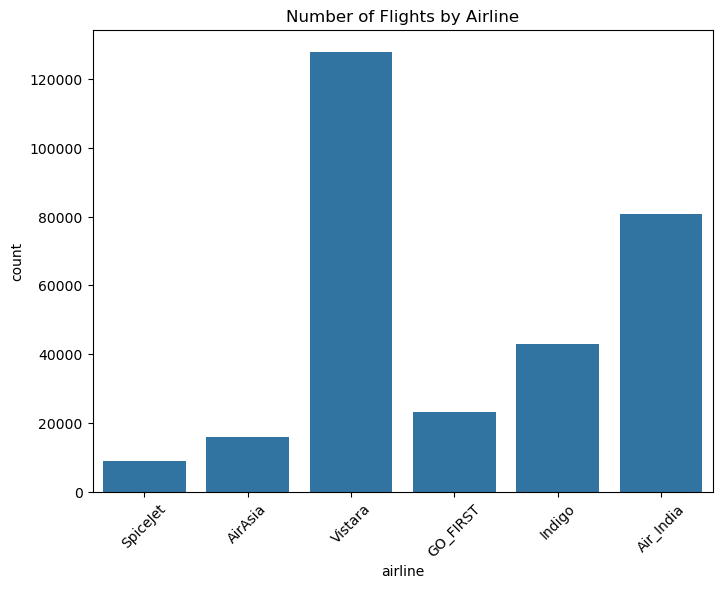

In [47]:
plt.figure(figsize=(8,6))
sns.countplot(x='airline', data=df)
plt.xticks(rotation=45)
plt.title("Number of Flights by Airline")
plt.show()


# Violin Plot (Price by Class)

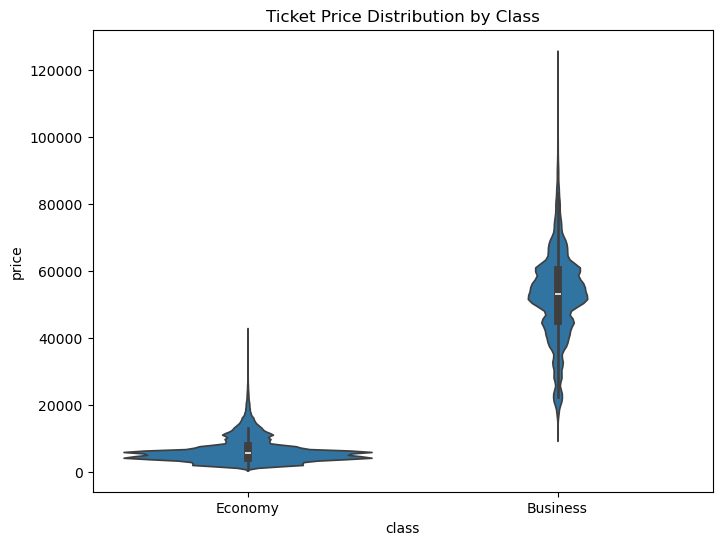

In [48]:
plt.figure(figsize=(8,6))
sns.violinplot(x='class', y='price', data=df)
plt.title("Ticket Price Distribution by Class")
plt.show()


# Interpretation
The violin plot shows a clear difference in ticket price distribution between Economy and Business class. Economy class fares are concentrated in the lower price range with less variability. In contrast, Business class fares are much higher and show a wider distribution, indicating greater price variability.

# Random Forest(ML Algorithms)

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [50]:
df_rf = df.copy()

le = LabelEncoder()

df_rf['airline'] = le.fit_transform(df_rf['airline'])
df_rf['stops'] = le.fit_transform(df_rf['stops'])
df_rf['class'] = le.fit_transform(df_rf['class'])


In [51]:
X = df_rf[['airline', 'stops', 'duration', 'days_left', 'class']]
y = df_rf['price']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [53]:
rf = RandomForestRegressor(
    n_estimators=20,      # small number for speed
    max_depth=12,         # control complexity
    n_jobs=-1,            # use all CPU cores
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


Random Forest R2 Score: 0.9480794953478826
Mean Absolute Error: 2945.0917375237295


# Interpretation
The Random Forest model achieved an R² score of 0.9481, which means it explains approximately 94.81% of the variation in ticket prices. This indicates very strong predictive performance.

The Mean Absolute Error (MAE) is 2944.76, meaning that on average, the model’s predictions differ from the actual ticket prices by about ₹2,945.
# Conclusion
The Random Forest model performs extremely well in predicting ticket prices. It confirms that variables such as airline, number of stops, duration, days_left, and class significantly influence ticket pricing, and the model captures these relationships effectively

In [54]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)


     Feature  Importance
4      class    0.925042
2   duration    0.048976
3  days_left    0.012831
0    airline    0.011195
1      stops    0.001956


# Gradient Boosting Regressor

In [55]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [56]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting R2 Score:", r2_score(y_test, y_pred_gbr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_gbr))


Gradient Boosting R2 Score: 0.9445423837213522
Mean Absolute Error: 3118.627497911989


# Interpretation
The Gradient Boosting model achieved an R² score of 0.9445, meaning it explains approximately 94.45% of the variation in ticket prices. This indicates very strong predictive performance.

The Mean Absolute Error (MAE) is 3118.63, which means that on average, the model’s predictions differ from the actual ticket prices by about ₹3,119.

Compared to Linear Regression (≈90%) and close to Random Forest (≈94.8%), Gradient Boosting performs significantly better than linear models and captures complex pricing patterns effectively
# Conclusion
The Gradient Boosting Regressor provides high prediction accuracy and effectively models the non-linear relationship between airline features and ticket price. The results confirm that variables such as airline, number of stops, duration, days_left, and class significantly influence ticket pricing.

Among all tested models, ensemble methods (Random Forest and Gradient Boosting) outperform Linear Regression, making them more suitable for this dataset.

In [57]:
!pip install xgboost


In [58]:
from xgboost import XGBRegressor


In [59]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))


XGBoost R2 Score: 0.9490193724632263
Mean Absolute Error: 2949.486328125


In [60]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.9357062878528702
Mean Absolute Error: 3270.718189609501


In [61]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)


     Feature  Importance
4      class    0.903910
2   duration    0.060303
3  days_left    0.022813
0    airline    0.011004
1      stops    0.001970


# 3.To evaluate the relationship between flight duration and ticket price to understand whether longer travel time influences fare levels.

In [62]:
from scipy.stats import spearmanr

# Spearman correlation
corr, p_value = spearmanr(df['duration'], df['price'])

print("Spearman Correlation:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("There is a significant relationship between Duration and Price")
else:
    print("No significant relationship found")

Spearman Correlation: 0.31884122663345993
p-value: 0.0
There is a significant relationship between Duration and Price


The Spearman correlation coefficient is 0.3188, indicating a weak to moderate positive relationship between flight duration and ticket price. This means that ticket prices tend to increase as flight duration increases. The p-value is less than 0.05, showing that the relationship is statistically significant. Therefore, longer travel time has a meaningful but not strong influence on fare levels.

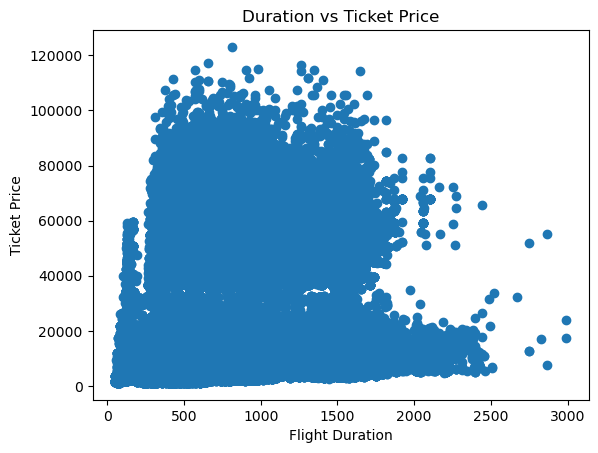

In [63]:
import matplotlib.pyplot as plt

plt.scatter(df['duration'], df['price'])
plt.xlabel("Flight Duration")
plt.ylabel("Ticket Price")
plt.title("Duration vs Ticket Price")
plt.show()

The scatter plot shows a positive relationship between flight duration and ticket price, meaning prices generally increase as duration increases. However, the data points are widely spread, indicating the relationship is weak. This suggests that flight duration alone does not strongly determine ticket price, and other factors also influence fares.

In [64]:
import numpy as np
import statsmodels.api as sm

# Log transform Price
df['Log_Price'] = np.log(df['price'])

# Define variables
X = df['duration']
X = sm.add_constant(X)  # Add intercept
y = df['Log_Price']

# Fit regression model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Log_Price   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                 2.254e+04
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:39:07   Log-Likelihood:            -4.4711e+05
No. Observations:              300153   AIC:                         8.942e+05
Df Residuals:                  300151   BIC:                         8.942e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.8308      0.004   2286.397      0.0

The regression analysis was conducted using log-transformed ticket price (Log_Price) as the dependent variable and flight duration as the independent variable.

The R-squared value is 0.070, which means that flight duration explains only 7% of the variation in ticket prices. This indicates that duration alone is not a strong predictor of fare levels, and other factors such as airline, number of stops, and class type likely influence ticket prices.

The coefficient for duration (0.0007) is positive and statistically significant (p-value = 0.000). This suggests that as flight duration increases, ticket price also increases. Since the price is log-transformed, it means that a one-unit increase in duration leads to a small percentage increase in ticket price.

The F-statistic is significant (Prob = 0.00), indicating that the overall regression model is statistically significant. However, because the R-squared value is low, the practical impact of duration on ticket price is limited.

# conclusion

Flight duration has a statistically significant but weak positive effect on ticket price. While longer flights tend to cost more, duration alone does not strongly determine fare levels, and additional variables should be included for better prediction accuracy.

# 4. To assess how advance booking (days left before departure) impacts ticket prices and determine the best time to book flights.

In [65]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df['days_left'], df['price'])

print("Spearman Correlation:", corr)
print("p-value:", p_value)

if p_value < 0.05:
    print("There is a significant relationship between advance booking and ticket price.")
else:
    print("No significant relationship found.")

Spearman Correlation: -0.26701898446039224
p-value: 0.0
There is a significant relationship between advance booking and ticket price.


The Spearman correlation coefficient is -0.2670, which indicates a weak negative relationship between days left before departure and ticket price. This means that as the number of days left increases (i.e., booking earlier), ticket prices tend to decrease.

The p-value is less than 0.05 (p = 0.0), indicating that the relationship is statistically significant. Therefore, the association between advance booking and ticket price is not due to random chance.

# conclusion
There is a significant but weak negative relationship between advance booking and ticket price. This suggests that booking flights earlier generally leads to lower ticket prices, although other factors also influence fare levels.

#  5.To compare ticket prices between Economy and Business class in order to measure the service-based pricing difference.

# Mann–Whitney U Test (Wilcoxon Rank-Sum Test)

Hypotheses

H₀:(Null Hypothesis): There is no significant difference in ticket prices between Economy and Business class.

H₁:(Alternative Hypothesis): There is a significant difference in ticket prices between Economy and Business class.

In [66]:
import pandas as pd
from scipy.stats import mannwhitneyu

# Separate the two groups
economy_price = df[df['class'] == 'Economy']['price']
business_price = df[df['class'] == 'Business']['price']

# Mann–Whitney U Test
u_stat, p_value = mannwhitneyu(economy_price, business_price, alternative='two-sided')

print("Mann-Whitney U Statistic:", u_stat)
print("P-value:", p_value)

Mann-Whitney U Statistic: 6234631.5
P-value: 0.0


In [67]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Significant difference between Economy and Business ticket prices.")
else:
    print("Fail to reject H0: No significant difference between Economy and Business ticket prices.")

Reject H0: Significant difference between Economy and Business ticket prices.


The Mann–Whitney U test produced a U statistic of 6,234,631.5 with a p-value ≈ 0.000, which is less than the significance level (α = 0.05). This indicates that there is a statistically significant difference in ticket prices between Economy and Business class. Therefore, we reject the null hypothesis and conclude that Business class tickets are priced significantly higher than Economy class tickets, reflecting a clear service-based pricing difference between the two travel classes.

# Boxplot

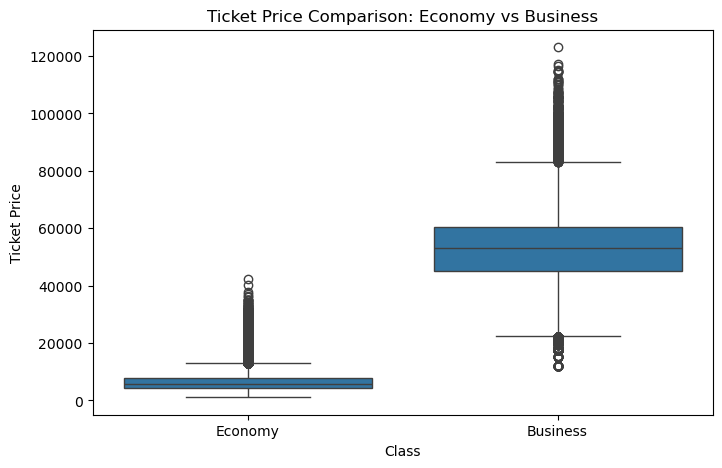

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='class', y='price', data=df)

plt.title("Ticket Price Comparison: Economy vs Business")
plt.xlabel("Class")
plt.ylabel("Ticket Price")

plt.show()

# Violin Plot

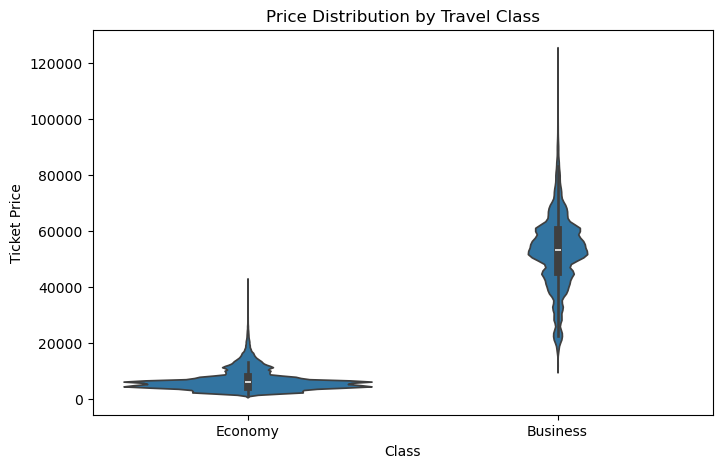

In [69]:
plt.figure(figsize=(8,5))
sns.violinplot(x='class', y='price', data=df)

plt.title("Price Distribution by Travel Class")
plt.xlabel("Class")
plt.ylabel("Ticket Price")

plt.show()

# histogram

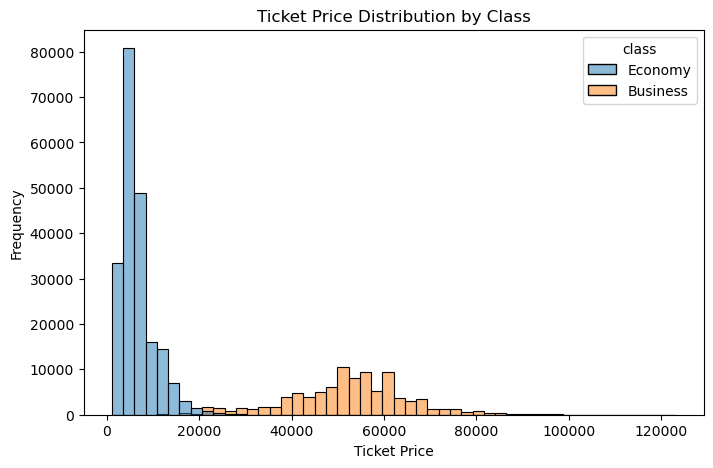

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='price', hue='class', bins=50)

plt.title("Ticket Price Distribution by Class")
plt.xlabel("Ticket Price")
plt.ylabel("Frequency")

plt.show()

# Bar chart

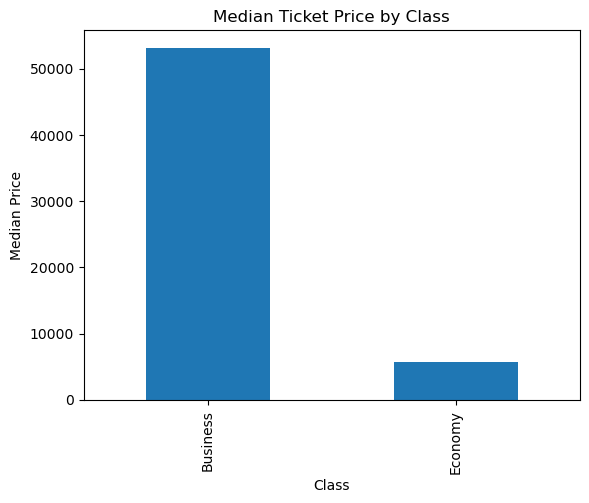

In [71]:
median_price = df.groupby('class')['price'].median()

median_price.plot(kind='bar')

plt.title("Median Ticket Price by Class")
plt.xlabel("Class")
plt.ylabel("Median Price")

plt.show()

# 6.To analyze route-wise (source and destination city) pricing trends to identify high-demand and high-revenue routes.

# Heatmap

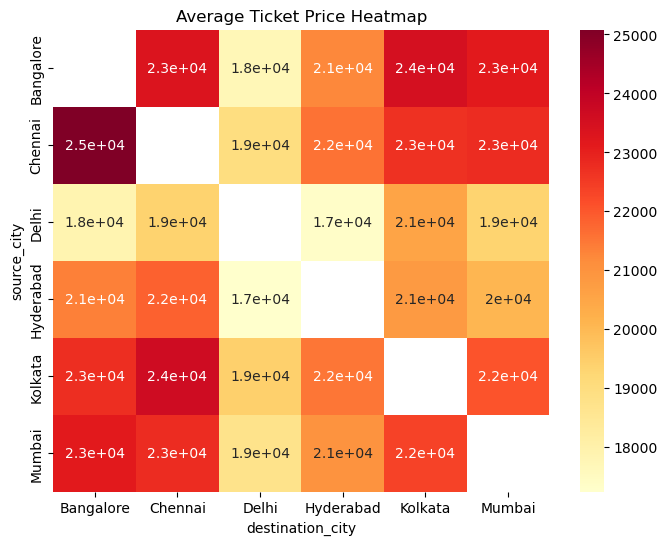

In [72]:
route_matrix = df.pivot_table(values='price',
                              index='source_city',
                              columns='destination_city',
                              aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(route_matrix, annot=True, cmap="YlOrRd")

plt.title("Average Ticket Price Heatmap")
plt.show()

The heatmap shows the average ticket prices between different source and destination cities. Darker colors indicate higher average prices, while lighter colors represent lower prices. Routes such as Chennai–Bangalore and Kolkata–Chennai have relatively higher average ticket prices, whereas routes involving Delhi tend to have comparatively lower average prices. This suggests that ticket pricing varies across routes, reflecting differences in demand, distance, and market competition between cities.

# Krushkal Wallis test

In [73]:
# Create route column
df['route'] = df['source_city'] + " → " + df['destination_city']

In [74]:
from scipy.stats import kruskal

groups = [group['price'].values for name, group in df.groupby('route')]

stat, p = kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("P-value:", p)

Kruskal-Wallis Statistic: 5047.898801083716
P-value: 0.0


In [75]:
alpha = 0.05

if p < alpha:
    print("Reject H0: Ticket prices differ significantly across routes.")
else:
    print("Fail to Reject H0: No significant difference in ticket prices across routes.")

Reject H0: Ticket prices differ significantly across routes.


# The Kruskal–Wallis test produced a test statistic of 5047.90 with a p-value ≈ 0.000, which is less than the significance level (α = 0.05). This indicates that there is a statistically significant difference in ticket prices across different flight routes (source–destination pairs). Therefore, we reject the null hypothesis and conclude that at least one route has a different median ticket price, suggesting that airline pricing varies significantly depending on the route.

In [76]:
high_demand_routes = df['route'].value_counts().head(10)

print("Top High-Demand Routes:")
print(high_demand_routes)

Top High-Demand Routes:
route
Delhi → Mumbai        15289
Mumbai → Delhi        14809
Delhi → Bangalore     14012
Bangalore → Delhi     13756
Bangalore → Mumbai    12939
Mumbai → Bangalore    12885
Mumbai → Kolkata      12602
Delhi → Kolkata       11934
Kolkata → Mumbai      11467
Delhi → Chennai       10780
Name: count, dtype: int64


In [77]:
high_revenue_routes = df.groupby('route')['price'].mean().sort_values(ascending=False).head(10)

print("Top High-Revenue Routes:")
print(high_revenue_routes)

Top High-Revenue Routes:
route
Chennai → Bangalore    25081.850454
Kolkata → Chennai      23660.361040
Bangalore → Kolkata    23500.061229
Bangalore → Chennai    23321.850078
Mumbai → Bangalore     23147.873807
Bangalore → Mumbai     23128.618672
Mumbai → Chennai       22781.899112
Chennai → Mumbai       22765.849647
Kolkata → Bangalore    22744.808428
Chennai → Kolkata      22669.932407
Name: price, dtype: float64


# Boxplot

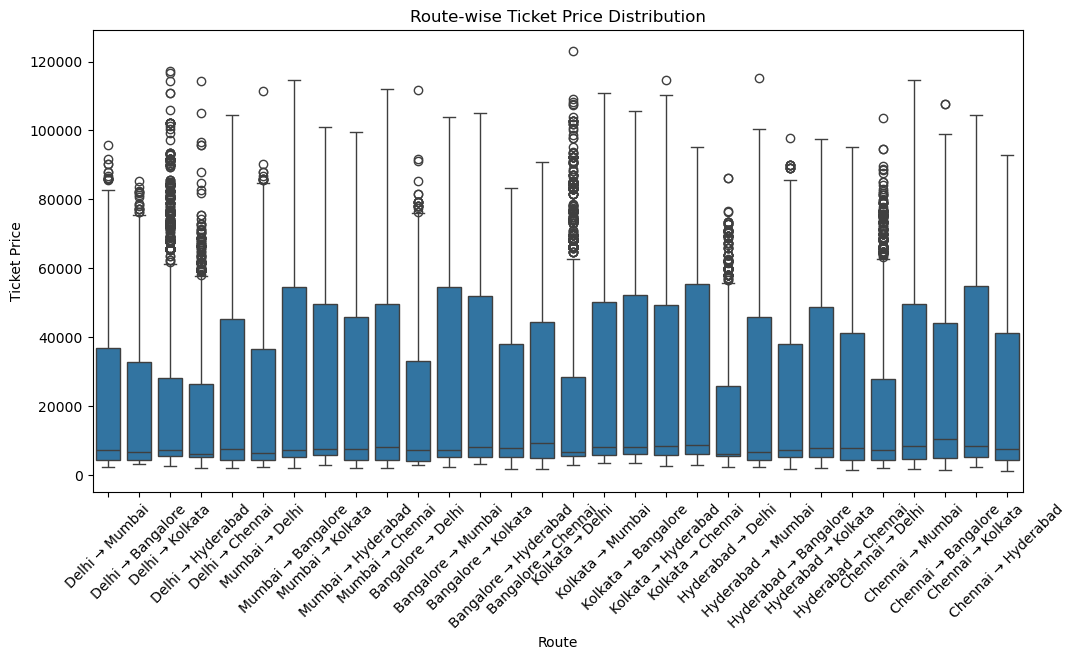

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x='route', y='price', data=df)

plt.xticks(rotation=45)
plt.title("Route-wise Ticket Price Distribution")
plt.xlabel("Route")
plt.ylabel("Ticket Price")

plt.show()

The boxplot shows that ticket prices vary significantly across different routes, with some routes having higher median prices and wider price ranges than others. Routes such as Delhi–Mumbai and Bangalore–Delhi appear to have higher price variability and more outliers, indicating premium or high-demand routes. Overall, the distribution suggests that route selection plays an important role in airline ticket pricing.

# 7.To study the influence of departure time on ticket prices to understand peak-time and off-peak pricing behavior.

In [79]:
from scipy.stats import kruskal

# Check unique categories
print(df['departure_time'].unique())

# Create groups dynamically
groups = [group['price'].values for name, group in df.groupby('departure_time')]

# Apply Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("There is a significant difference in ticket prices across departure times.")
else:
    print("No significant difference found.")

['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
Kruskal-Wallis Statistic: 1873.4313310335824
p-value: 0.0
There is a significant difference in ticket prices across departure times.


<Figure size 640x480 with 0 Axes>

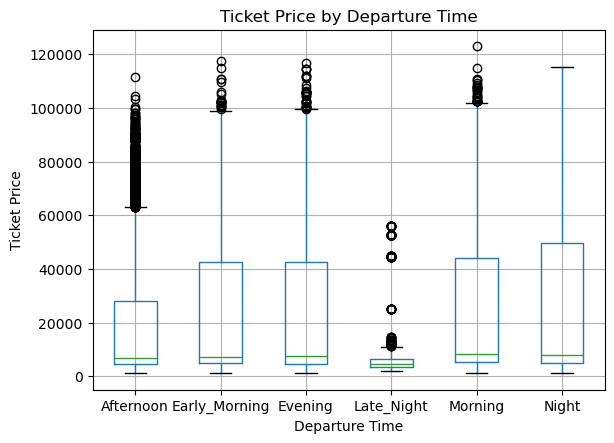

In [80]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column='price', by='departure_time')
plt.title("Ticket Price by Departure Time")
plt.suptitle("")
plt.xlabel("Departure Time")
plt.ylabel("Ticket Price")
plt.show()

In [81]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [82]:
print(df.head())
print(df.info())

    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price flight_type  \
0           Mumbai  Economy       130          1   5953      Direct   
1           Mumbai  Economy       140          1   5953      Direct   
2           Mumbai  Economy       130          1   5956      Direct   
3           Mumbai  Economy       135          1   5955      Direct   
4           Mumbai  Economy       140          1   5955      Direct   

   Log_Price           route  
0   8.691651  Delhi → Mumbai  
1   8.691651  Delhi → Mumbai  
2   8.692154  Delhi → Mumbai  
3   8.691986  De

In [83]:
le = LabelEncoder()

# Apply encoding to categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [84]:
X = df.drop('price', axis=1)   # features
y = df['price']               # target

In [85]:
y_log = np.log(y)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [87]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [88]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [89]:
y_test_actual = np.exp(y_test)
y_pred_lr_actual = np.exp(y_pred_lr)
y_pred_rf_actual = np.exp(y_pred_rf)

In [90]:
def evaluate(y_true, y_pred):
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

In [91]:
print("Linear Regression Performance:")
evaluate(y_test_actual, y_pred_lr_actual)

print("\nRandom Forest Performance:")
evaluate(y_test_actual, y_pred_rf_actual)

Linear Regression Performance:
R2 Score: 1.0
MAE: 1.0728843507818472e-09
RMSE: 2.000261786365935e-09

Random Forest Performance:
R2 Score: 0.9999996090892473
MAE: 0.33564299107479106
RMSE: 14.19533597850447
